In [ ]:
!pip install prophet xgboost tensorflow openpyxl fastapi uvicorn -q

In [ ]:

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
df = pd.read_excel('Forecasting Case- Study.xlsx')

print(df.head())
print(df.shape)

        State                 Date        Total   Category
0     Alabama  2019-01-12 00:00:00  109574036.0  Beverages
1     Arizona  2019-01-12 00:00:00  109101594.6  Beverages
2    Arkansas  2019-01-12 00:00:00   58049432.2  Beverages
3  California  2019-01-12 00:00:00  444766890.6  Beverages
4    Colorado  2019-01-12 00:00:00   89816716.3  Beverages
(8084, 4)


In [ ]:

df = pd.read_excel('Forecasting Case- Study.xlsx')

print(df.head())
print(df.shape)


        State                 Date        Total   Category
0     Alabama  2019-01-12 00:00:00  109574036.0  Beverages
1     Arizona  2019-01-12 00:00:00  109101594.6  Beverages
2    Arkansas  2019-01-12 00:00:00   58049432.2  Beverages
3  California  2019-01-12 00:00:00  444766890.6  Beverages
4    Colorado  2019-01-12 00:00:00   89816716.3  Beverages
(8084, 4)



# Data Cleaning and Preprocessing


In [ ]:

df.columns = ['State', 'Date', 'Sales', 'Category']

df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values(['State', 'Date'])

df['Sales'] = df['Sales'].fillna(method='ffill')

weekly_df = df.groupby(['State', 'Date'])['Sales'].sum().reset_index()

weekly_df.head()


,State,Date,Sales
0,Alabama,2019-01-12,109574036.0
1,Alabama,2019-03-11,112189103.8
2,Alabama,2019-06-10,129106730.4
3,Alabama,2019-08-12,108083723.8
4,Alabama,2019-10-11,110932912.8



# Feature Engineering


In [ ]:

def create_features(data):

    data = data.copy()

    data['lag_1'] = data['Sales'].shift(1)
    data['lag_7'] = data['Sales'].shift(7)
    data['lag_30'] = data['Sales'].shift(30)

    data['rolling_mean_7'] = data['Sales'].rolling(7).mean()
    data['rolling_std_7'] = data['Sales'].rolling(7).std()

    data['month'] = data['Date'].dt.month
    data['week'] = data['Date'].dt.isocalendar().week.astype(int)
    data['day_of_week'] = data['Date'].dt.dayofweek

    data = data.dropna()

    return data


In [ ]:

state_name = weekly_df['State'].unique()[0]

state_df = weekly_df[weekly_df['State'] == state_name].copy()

state_df = create_features(state_df)

state_df.head()


,State,Date,Sales,lag_1,lag_7,lag_30,rolling_mean_7,rolling_std_7,month,week,day_of_week
30,Alabama,2020-05-07,138414683.2,123259529.2,127145065.2,109574036.0,1.217345e+08,1.143778e+07,5,19,3
31,Alabama,2020-05-17,130340051.0,138414683.2,116657084.0,112189103.8,1.236892e+08,1.159357e+07,5,20,6
32,Alabama,2020-05-24,134708618.7,130340051.0,133713630.0,129106730.4,1.238314e+08,1.174210e+07,5,21,6
33,Alabama,2020-05-31,129887876.9,134708618.7,117742073.2,108083723.8,1.255665e+08,1.158871e+07,5,22,6
34,Alabama,2020-06-09,137905687.0,129887876.9,118114595.0,110932912.8,1.283938e+08,1.187827e+07,6,24,1



# Train Test Split


In [ ]:

train_size = int(len(state_df) * 0.8)

train = state_df.iloc[:train_size]
test = state_df.iloc[train_size:]

features = [
    'lag_1',
    'lag_7',
    'lag_30',
    'rolling_mean_7',
    'rolling_std_7',
    'month',
    'week',
    'day_of_week'
]

X_train = train[features]
X_test = test[features]

y_train = train['Sales']
y_test = test['Sales']



# Model 1 - SARIMA


In [ ]:

sarima_model = SARIMAX(
    train['Sales'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_result = sarima_model.fit(disp=False)

sarima_pred = sarima_result.forecast(steps=len(test))

sarima_mae = mean_absolute_error(y_test, sarima_pred)

print("SARIMA MAE:", sarima_mae)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


SARIMA MAE: 26932407.910138614


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(



# Model 2 - Prophet


In [ ]:

prophet_df = train[['Date', 'Sales']].rename(
    columns={'Date':'ds', 'Sales':'y'}
)

prophet_model = Prophet()

prophet_model.fit(prophet_df)

future = prophet_model.make_future_dataframe(
    periods=len(test),
    freq='W'
)

forecast = prophet_model.predict(future)

prophet_pred = forecast['yhat'].tail(len(test)).values

prophet_mae = mean_absolute_error(y_test, prophet_pred)

print("Prophet MAE:", prophet_mae)


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Prophet MAE: 53559239.28987177



# Model 3 - XGBoost


In [ ]:

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)

print("XGBoost MAE:", xgb_mae)


XGBoost MAE: 13348995.278125



# Model 4 - LSTM


In [ ]:

scaler = MinMaxScaler()

scaled_train = scaler.fit_transform(train[['Sales']])
scaled_test = scaler.transform(test[['Sales']])

def create_sequences(data, seq_length=4):

    X = []
    y = []

    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i])

    return np.array(X), np.array(y)

X_lstm_train, y_lstm_train = create_sequences(scaled_train)
X_lstm_test, y_lstm_test = create_sequences(scaled_test)

model = Sequential([
    LSTM(64, activation='relu', input_shape=(X_lstm_train.shape[1], 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(
    monitor='loss',
    patience=5
)

model.fit(
    X_lstm_train,
    y_lstm_train,
    epochs=20,
    batch_size=8,
    verbose=0,
    callbacks=[early_stop]
)

lstm_pred = model.predict(X_lstm_test)

lstm_pred = scaler.inverse_transform(lstm_pred)

actual_lstm = scaler.inverse_transform(
    y_lstm_test.reshape(-1,1)
)

lstm_mae = mean_absolute_error(
    actual_lstm,
    lstm_pred
)

print("LSTM MAE:", lstm_mae)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
LSTM MAE: 9487036.167857142



# Compare Model Performance


In [ ]:

results = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost', 'LSTM'],
    'MAE': [sarima_mae, prophet_mae, xgb_mae, lstm_mae]
})

results = results.sort_values('MAE')

results


,Model,MAE
3,LSTM,9.487036e+06
2,XGBoost,1.334900e+07
0,SARIMA,2.693241e+07
1,Prophet,5.355924e+07



# Best Model


In [ ]:

best_model = results.iloc[0]['Model']

print("Best Performing Model:", best_model)


Best Performing Model: LSTM



# Forecast Next 8 Weeks


In [ ]:

future_forecast = sarima_result.forecast(steps=8)

forecast_df = pd.DataFrame({
    'Week': range(1,9),
    'Forecasted_Sales': future_forecast.values
})

forecast_df


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


,Week,Forecasted_Sales
0,1,2.064633e+08
1,2,2.060870e+08
2,3,2.200083e+08
3,4,2.159483e+08
4,5,2.095199e+08
5,6,2.145067e+08
6,7,2.186828e+08
7,8,2.166104e+08



# Visualization


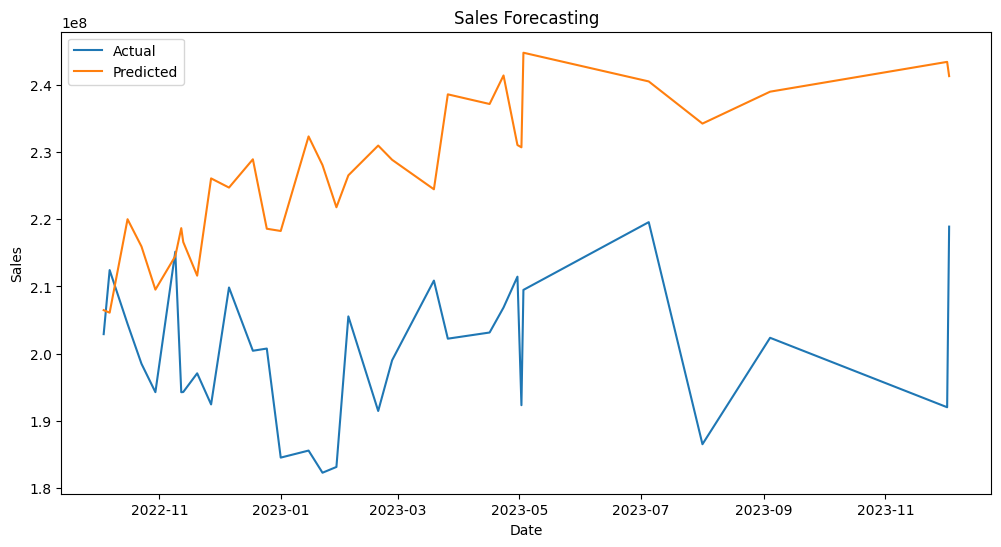

In [ ]:

plt.figure(figsize=(12,6))

plt.plot(test['Date'], y_test.values, label='Actual')
plt.plot(test['Date'], sarima_pred.values, label='Predicted')

plt.title('Sales Forecasting')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.legend()

plt.show()



# FastAPI Example


In [ ]:

api_code = '''

from fastapi import FastAPI

app = FastAPI()

@app.get("/")
def home():
    return {"message": "Forecast API Running"}

@app.get("/forecast")
def forecast():
    return {
        "week_1": 1000,
        "week_2": 1200,
        "week_3": 1300
    }
'''

with open("app.py", "w") as f:
    f.write(api_code)

print("app.py created")


app.py created
